In [21]:
import matplotlib.colors as mcolors
from scipy.integrate import quad
import matplotlib.pyplot as plt
from main_funcs import *
import matplotlib as mpl
import numpy as np
import pickle

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    'font.size'           : 14,            # body text size (most journals use 10 pt)
    'axes.titlesize'      : 14,
    'axes.labelsize'      : 14,            # axis-label size matches body text
    'xtick.labelsize'     : 14,             # tick labels one point smaller
    'ytick.labelsize'     : 14,
    'legend.fontsize'     : 14,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


In [2]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [3]:
def theta_max(lam,gamma=29.303431969091314):
    return np.arcsin(np.sqrt(lam*(1-lam))/(gamma*lam))

In [35]:
N = 10000

theta = data_all["With New"][0]["Y"][:, 0]
lambdas = data_all["With New"][0]["X"][0, :]

lambda_curr = 0.500
i_lambda = np.argmin(np.abs(lambdas - lambda_curr))

Z_i = data_all["With New"][7]["Z"][:,i_lambda]
Z_without = data_all["Without New"][7]["Z"][:,i_lambda]
w_diff = np.abs(Z_i-Z_without)

w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.5_budget=2540.npz", allow_pickle=True)
w_cma = w_cma["weight"][:,i_lambda]

w0 = w_cma#np.ones_like(theta)

num_sum = np.zeros_like(theta, dtype=float)
den_sum = np.zeros_like(theta, dtype=float)

for run_id, grids in data_all["With New"].items():
    Zcol = grids["Z"][:, i_lambda]
    p = N * Zcol * 1e-3

    A = np.sum(p * w0)
    B = np.sum(p * w0 * theta)
    C = np.sum(p * w0 * theta**2)
    D = np.sum(p * w0**2)

    y  = B / A
    s2 = C / A - (B / A)**2
    sigma2 = s2 * D / A**2

    Delta = theta - y
    a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

    b = (y * A) / D

    weight = (y * p) / sigma2
    num_sum += weight * a
    den_sum += weight * b
    
eps = 1e-30
mask = den_sum > eps

w_opt = np.zeros_like(theta, dtype=float)
w_opt[mask] = num_sum[mask] / den_sum[mask]

w_opt = np.maximum(0.0, w_opt)

In [5]:
a = theta_max(lambdas[i_lambda])*1e3
b = abs(theta[np.nanargmax(w_opt)])
c = np.abs(a-b)/a * 100
print(a,b,c)

37.728690194352076 37.27454909819642 1.2037022589870972


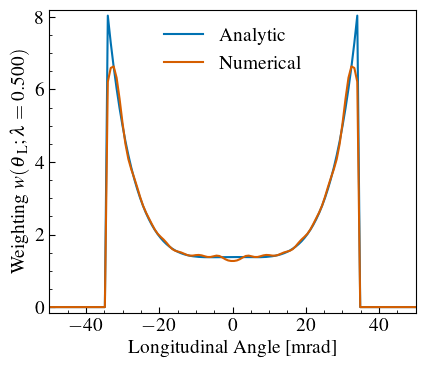

In [37]:
w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.5_budget=2540.npz", allow_pickle=True)

mm = 1 / 25.4

fig, ax = plt.subplots(
figsize=(120 * mm, 100 * mm)
)

ax.plot(theta, w_opt, label="Analytic")
ax.plot(theta, w_cma["weight"][:,i_lambda], label="Numerical")
ax.set_ylabel(r"Weighting $w(\theta\,_\mathrm{L};\lambda=0.500)$")
ax.set_xlabel(r"Longitudinal Angle [mrad]")
plt.legend()
ax.set_xlim([-50, 50])
# plt.savefig("outputs/analytic weighting slice.png")
plt.savefig("final diss plots/analytic weighting slice.png")
plt.show()

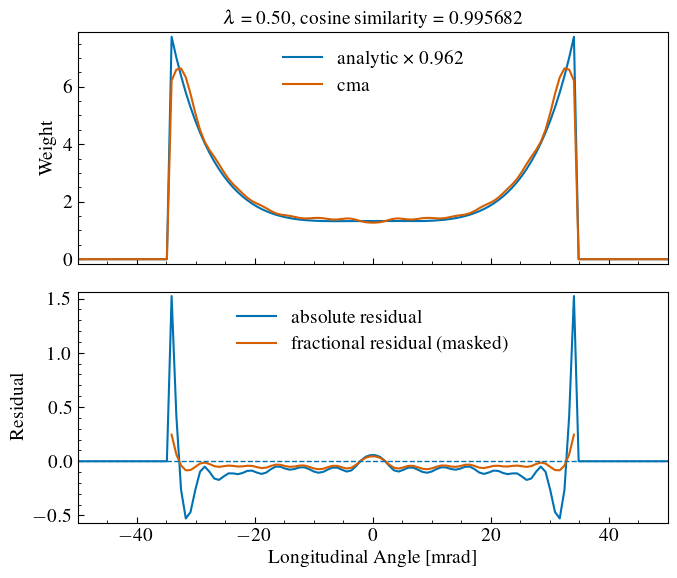

In [38]:
w_cma_slice = w_cma["weight"][:, i_lambda]
lam_targets = data_all["With New"][0]["X"][0,:]

# --- mask out near-zero regions (important for stability) ---
mask = w_cma_slice > 0.05 * np.max(w_cma_slice)

wa = w_opt[mask]
wc = w_cma_slice[mask]

# --- best-fit scale factor (analytic → cma) ---
c = np.sum(wa * wc) / np.sum(wa**2)

w_opt_scaled = c * w_opt

# --- cosine similarity (scale invariant) ---
cos_sim = np.sum(w_opt * w_cma_slice) / np.sqrt(
    np.sum(w_opt**2) * np.sum(w_cma_slice**2)
)

# --- residuals ---
residual = w_opt_scaled - w_cma_slice

# optional: fractional residual (masked)
frac = np.full_like(w_cma_slice, np.nan, dtype=float)
frac[mask] = (w_opt_scaled[mask] - w_cma_slice[mask]) / w_cma_slice[mask]

# --- plotting ---
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# TOP: overlay
ax[0].plot(theta, w_opt_scaled, label=f'analytic × {c:.3f}')
ax[0].plot(theta, w_cma_slice, label='cma')
ax[0].set_ylabel('Weight')
ax[0].legend()
ax[0].set_title(fr'$\lambda$ = {lam_targets[i_lambda]:.2f}, cosine similarity = {cos_sim:.6f}')

# BOTTOM: residuals
ax[1].plot(theta, residual, label='absolute residual')
ax[1].plot(theta, frac, label='fractional residual (masked)')
ax[1].axhline(0, linestyle='--', linewidth=1)
ax[1].set_xlabel(r'Longitudinal Angle [mrad]')
ax[1].set_ylabel('Residual')
ax[1].legend()

ax[1].set_xlim([-50, 50])

plt.tight_layout()
plt.savefig("outputs/weighting slice analytic.png")
plt.show()

In [8]:
FOM_opt = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: np.tile(w_opt[:, None], (1, X.shape[1])))
FOM_cma = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: w_cma["weight"])
print(FOM_opt['FOM']/FOM_cma['FOM'], FOM_cma['FOM']/FOM_cma['FOM'])

1.0022618419909177 1.0


In [9]:
def weight_per_lam(lam, w0=np.ones_like(theta), N=1e5):
    i_lambda = np.argmin(np.abs(lambdas - lam))

    num_sum = np.zeros_like(theta, dtype=float)
    den_sum = np.zeros_like(theta, dtype=float)

    for run_id, grids in data_all["With New"].items():
        Zcol = grids["Z"][:, i_lambda]
        p = N * Zcol * 1e-3

        A = np.sum(p * w0)
        B = np.sum(p * w0 * theta)
        C = np.sum(p * w0 * theta**2)
        D = np.sum(p * w0**2)

        y  = B / A
        s2 = C / A - (B / A)**2
        sigma2 = s2 * D / A**2

        Delta = theta - y
        a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

        b = (y * A) / D

        weight = (y * p) / sigma2
        num_sum += weight * a
        den_sum += weight * b
        
    eps = 1e-30
    mask = den_sum > eps

    w_opt = np.zeros_like(theta, dtype=float)
    w_opt[mask] = num_sum[mask] / den_sum[mask]

    w_opt = np.maximum(0.0, w_opt)
    return w_opt

In [11]:
w_tot = []

w_cma_full = np.load("total_interpolated_weights.npz", allow_pickle=True)

for lam in lambdas:
    i_lambda = np.argmin(np.abs(lambdas - lam))
    w0_curr = w_cma_full["weight"][:,i_lambda]
    w_curr = weight_per_lam(lam)#,w0=w0_curr)
    w_tot.append(w_curr)

C:\Users\JakeS\AppData\Local\Temp\ipykernel_32332\77451542.py:16: RuntimeWarning: invalid value encountered in scalar divide
  y  = B / A
C:\Users\JakeS\AppData\Local\Temp\ipykernel_32332\77451542.py:17: RuntimeWarning: invalid value encountered in scalar divide
  s2 = C / A - (B / A)**2


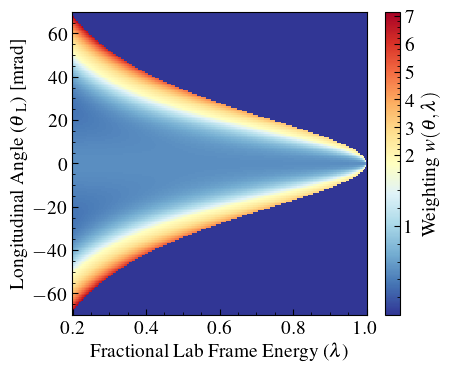

In [25]:
X = data_all["With New"][0]["X"]
Y = data_all["With New"][0]["Y"]
Z = data_all["With New"][0]["Z"]

w_tot = np.array(w_tot)

cmap = plt.get_cmap("RdYlBu_r")
norm = mcolors.TwoSlopeNorm(
    vmin=w_tot.min(),
    vcenter=1.7,   # physics-dominant region
    vmax=w_tot.max()
)

np.savez_compressed("analytic_weights_cma_lead.npz",weight=w_tot)

mm = 1 / 25.4

fig2, ax2 = plt.subplots(
figsize=(120 * mm, 100 * mm)
)
c = ax2.pcolormesh(X, Y, w_tot.T, shading="auto",cmap=cmap, norm=norm, rasterized=True)
ax2.set_xlabel(r"Fractional Lab Frame Energy ($\lambda$)")
ax2.set_ylabel(r"Longitudinal Angle ($\theta\,_\mathrm{L}$) [mrad]")
# ax2.set_title("Weighting phase space")
# ax2.set_facecolor("#F7F9FC")
# fig2.set_facecolor("#F7F9FC")
ax2.set_ylim([-70,70])
cbar = fig2.colorbar(c, ax=ax2, label=r"Weighting $w(\theta,\lambda)$")

ticks = np.arange(1,8)
cbar.set_ticks(ticks)
cbar.set_ticklabels(ticks)
fig2.tight_layout()
# plt.savefig("outputs/analytic weighting phase space.png")
plt.savefig("final diss plots/analytic weight map.png")
plt.show()

In [12]:
w_cma_tot = np.load("total_interpolated_weights.npz")["weight"]

cma_FOM = compute_fom_over_lambda(data_all,1e5,weight_func=lambda Y,X: w_cma["weight"])
analytic_FOM = compute_fom_over_lambda(data_all,1e5,weight_func=lambda Y,X: w_tot.T)
unweighted_FOM = compute_fom_over_lambda(data_all,1e5,weight_func=lambda Y,X: np.ones_like(w_tot))

In [13]:
print(np.nansum(analytic_FOM)/np.nansum(unweighted_FOM), np.nansum(analytic_FOM)/np.nansum(cma_FOM))

1.4486822583221142 322.0803201510304
